# Tarea — Unidad 4 · Preparación de datos para un modelo de riesgo de ictus (accidente cerebrovascular)

**FP13 · Inteligencia Artificial · UAG**
Subtemas 4.1 a 4.7

---

## Contexto

El **Stroke Prediction Dataset** contiene 5,110 registros de pacientes con 11 variables clínicas y
sociodemográficas. El desenlace `stroke` indica si el paciente presentó un evento cerebrovascular.

En la Práctica 7 trabajamos cada transformación por separado sobre datos de cardiopatía isquémica.
Aquí el encargo es distinto: **construir una matriz de modelado completa**, desde el archivo crudo
hasta la selección final de variables, y **justificar una decisión por columna**.

## Qué se evalúa

No se evalúa que el código corra: se evalúa que **cada decisión esté argumentada con evidencia
producida por usted**.

| Criterio | Peso |
|---|---|
| Corrección técnica del código (partes 1 a 9) | 40 % |
| Justificación escrita de cada decisión | 30 % |
| Tabla de decisiones por columna (Parte 10) | 15 % |
| Preguntas de reflexión | 15 % |

## Entrega

Este mismo notebook **ejecutado de arriba a abajo sin errores**, con todas las celdas de texto
completadas. Nombre el archivo `Tarea_U4_ApellidoNombre.ipynb`.

## Restricciones

- **No use `Pipeline` ni `ColumnTransformer`.** Todo se resuelve columna por columna, de forma
  explícita. Volveremos a encapsularlo en la Unidad 5.
- Fije la semilla al inicio y no la vuelva a tocar.
- Toda afirmación sobre los datos debe estar respaldada por una celda que la produzca.

---
## Parte 0 · Preparación

In [2611]:
# [1] Entorno y semilla
# TODO: importe numpy, pandas, matplotlib.pyplot y scipy.stats.
#       Fije SEED = 42 y configure la salida de pandas.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
SEED = 42


In [2612]:
# [2] Ingesta del conjunto de datos
# TODO: cargue "healthcare-dataset-stroke-data.csv" en un DataFrame llamado df.
#       Puede usar kagglehub (dataset "fedesoriano/stroke-prediction-dataset") (https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)
#       o la copia local. Imprima la forma y las primeras filas.
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


---
## Parte 1 · Reconocimiento (subtema 4.7)

Antes de modificar nada hay que saber qué se tiene. La clasificación de una variable en nominal,
binaria o numérica es una decisión **clínica**, no estadística: la toma usted, no `pandas`.

In [2613]:
# [3] Inventario de columnas
# TODO: construya una tabla con, por columna: tipo de dato, numero de valores unicos,
#       numero de nulos y porcentaje de nulos.
porcen =  df.isnull().sum() / (df.nunique()) * 100

inven = pd.DataFrame(
    {"Tipo de dato": df.dtypes,
     "Numero de valores unicos": df.nunique(), 
     "Numero de nulos": df.isnull().sum(),
     "Porcentaje de nulos": porcen.round(3)
    }
)

print(inven)

                  Tipo de dato  Numero de valores unicos  Numero de nulos  \
id                       int64                      5110                0   
gender                  object                         3                0   
age                    float64                       104                0   
hypertension             int64                         2                0   
heart_disease            int64                         2                0   
ever_married            object                         2                0   
work_type               object                         5                0   
Residence_type          object                         2                0   
avg_glucose_level      float64                      3979                0   
bmi                    float64                       418              201   
smoking_status          object                         4                0   
stroke                   int64                         2                0   

In [2614]:
# [4] Declaracion de roles
# TODO: defina las listas IDENT, NOMINALES, BINARIAS, INDICADOR, NUMERICAS y OBJETIVO.
#       Imprima las categorias de cada variable de texto con su frecuencia,
#       la prevalencia del objetivo y cuantos valores unicos toma la columna de folio.


IDENT     = "id"
NOMINALES = ['smoking_status', 'work_type']   # sin orden intrinseco
BINARIAS  = ['gender', 'Residence_type', 'ever_married']          # dos categorias de texto
INDICADOR = ['hypertension', 'heart_disease']           # ya vienen como 0/1
NUMERICAS = ['age', 'avg_glucose', 'bmi']
OBJETIVO  = "stroke"

print("Categorias de cada variable de texto:")
for c in NOMINALES + BINARIAS:
    print(f"  {c:<16} {dict(df[c].value_counts())}")

print(f"\nPrevalencia de ictus: {df[OBJETIVO].mean():.4f}")
print(f"Folios unicos: {df[IDENT].nunique()} de {len(df)} filas")

Categorias de cada variable de texto:
  smoking_status   {'never smoked': np.int64(1892), 'Unknown': np.int64(1544), 'formerly smoked': np.int64(885), 'smokes': np.int64(789)}
  work_type        {'Private': np.int64(2925), 'Self-employed': np.int64(819), 'children': np.int64(687), 'Govt_job': np.int64(657), 'Never_worked': np.int64(22)}
  gender           {'Female': np.int64(2994), 'Male': np.int64(2115), 'Other': np.int64(1)}
  Residence_type   {'Urban': np.int64(2596), 'Rural': np.int64(2514)}
  ever_married     {'Yes': np.int64(3353), 'No': np.int64(1757)}

Prevalencia de ictus: 0.0487
Folios unicos: 5110 de 5110 filas


**Responda antes de continuar.** Dos columnas categóricas contienen algo que no debería estar ahí:
una tiene una categoría con un solo paciente, otra tiene una categoría que no describe ninguna
condición clínica. Identifíquelas.

En la columna de gender hay un other que no debería estar y la columna de smoking_status con Unknown porque no aporta información para el pronóstico

---
## Parte 2 · Integridad de los registros: duplicados (subtema 4.7)

Eliminar duplicados es un paso obligatorio del protocolo. Pero *duplicado* no significa «filas
parecidas»: significa **el mismo paciente capturado dos veces**. Verifique en tres niveles **antes**
de borrar una sola fila.

In [2615]:
# [5] Tres niveles de verificacion
# TODO: cuente (1) duplicados exactos sobre todas las columnas,
#       (2) duplicados ignorando la columna de folio,
#       (3) filas que repiten una llave clinica formada por las categoricas + age.
#       Reporte cuantas filas y cuantos perfiles distintos involucra el nivel 3.
llave = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'age']
columnnas = [col for col in df.columns if col != 'id']

print(f'Duplicados exactos: {df.duplicated(subset=columnnas , keep = False).sum()}')
print(f'Duplicados ignorando la columna de folio: {df.duplicated(subset=columnnas, keep=False).sum()}')

conteo_grupos = df.groupby(llave).size()
perfiles_distintos= (conteo_grupos > 1).sum()

print(f'Perfiles distintos repetidos: {perfiles_distintos}')

Duplicados exactos: 0
Duplicados ignorando la columna de folio: 0
Perfiles distintos repetidos: 1141


In [2616]:
# [6] La prueba decisiva
# TODO: repita el conteo del nivel 3 agregando bmi y avg_glucose_level a la llave.
#       Muestre dos registros con el mismo perfil clinico y mediciones distintas.
#       Decida: que filas elimina y que columnas elimina. Ejecute su decision.
llave += ["bmi", 'avg_glucose_level']

grupo = df.groupby(llave).size()
perfiles_distintos_med = (grupo > 1).sum()
print(f'Perfiles distintos repetidos: {perfiles_distintos_med}')
grupo.head()


Perfiles distintos repetidos: 0


gender  ever_married  work_type  Residence_type  smoking_status   age   bmi   avg_glucose_level
Female  No            Govt_job   Rural           Unknown          23.0  22.2  71.81                1
                                                                  27.0  27.2  65.43                1
                                                                  37.0  20.4  76.21                1
                                                                  46.0  23.5  112.29               1
                                                 formerly smoked  18.0  23.2  112.33               1
dtype: int64

**Justifique su decisión.** ¿Cuántas filas eliminó y por qué? Si eliminó cero, dígalo
explícitamente y explique qué habría pasado con `drop_duplicates(subset=llave_clinica)`. Si eliminó
alguna columna, justifique por qué no aporta al modelo.

No eliminé ninguna, porque no todas las personas con un transfondo parecido tienen los mismo valores ya que de manera general es igual pero faltarían más datos para poder descartar, solo con un analisis de correlación se podrian discriminar.

---
## Parte 3 · Valores faltantes: los declarados y los enmascarados

En la Práctica 7 el faltante se disfrazaba de número (colesterol = 0 mg/dL). Aquí hay faltantes de
dos tipos y uno de ellos se disfraza de **texto**.

In [2617]:
# [7] Faltantes declarados y enmascarados
# TODO: (a) reporte los nulos declarados por columna.
#       (b) localice la categoria de texto que en realidad significa "dato no disponible"
#           y cuente cuantos registros la tienen.
#       (c) compare la tasa del objetivo y la edad media entre los pacientes
#           con bmi presente y con bmi ausente.

df_lim = df.copy()
df_lim.loc[df_lim["smoking_status"] == "Unknown", "smoking_status"] = np.nan
print(f'Registros sin datos con valor {(df_lim["smoking_status"].isna().sum())}')

bmi_desc = df["bmi"].isnull()

ind = ["age", "stroke", "bmi"]

bmi_con = df[~bmi_desc]
bmi_fal = df[bmi_desc]

prom_fal = bmi_fal[ind].mean()
prom_con = bmi_con[ind].mean()

print(f"Promedio datos faltantes \n{prom_fal}")
print(f"Promedio datos completos \n{prom_con}")

Registros sin datos con valor 1544
Promedio datos faltantes 
age       52.049154
stroke     0.199005
bmi             NaN
dtype: float64
Promedio datos completos 
age       42.865374
stroke     0.042575
bmi       28.893237
dtype: float64


**Interprete (c).** ¿El dato de `bmi` falta al azar? Si su respuesta es no, proponga un mecanismo
clínico que lo explique y diga qué consecuencia tiene para la imputación.

No debería, ya que es el indicador de salud estándar y más porque este puede ayudar a comprender su salud en general y ayudar a asociar con su gasto cardiaco. No obstante se puede deber debido a una dificultad o problema previo que haya complicado estas mediciones

In [2618]:
# [8] Mecanismo del faltante enmascarado
# TODO: calcule la proporcion de la categoria enmascarada segun work_type
#       y segun grupo de edad (use pd.cut con cortes 0-18-40-60-120).
#       Concluya si el patron es aleatorio.

proporcion = df.groupby(["work_type", pd.cut(df["age"], bins=[0, 18, 40, 60, 120], labels=['0-18', '19-40', '41-60', '61-120' ])])['bmi'].apply(lambda x: x.isna().mean()).unstack()

proporcion.head()



C:\Users\gada2\AppData\Local\Temp\ipykernel_15924\1975333877.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  proporcion = df.groupby(["work_type", pd.cut(df["age"], bins=[0, 18, 40, 60, 120], labels=['0-18', '19-40', '41-60', '61-120' ])])['bmi'].apply(lambda x: x.isna().mean()).unstack()


age,0-18,19-40,41-60,61-120
work_type,,,,
Govt_job,0.000000,0.043750,0.029412,0.060440
Never_worked,0.000000,0.000000,NaN,NaN
Private,0.027027,0.028116,0.034000,0.066865
Self-employed,0.000000,0.020202,0.042969,0.069042
children,0.023290,NaN,NaN,NaN


--- TABLA COMPARATIVA ---
     Versión    n     Media  Desv_Estd  Asimetría
  Observados 4908 28.894560   7.854320   1.054740
      Global 5109 28.863300   7.699785   1.087609
Condicionada 5109 28.872088   7.720712   1.069679


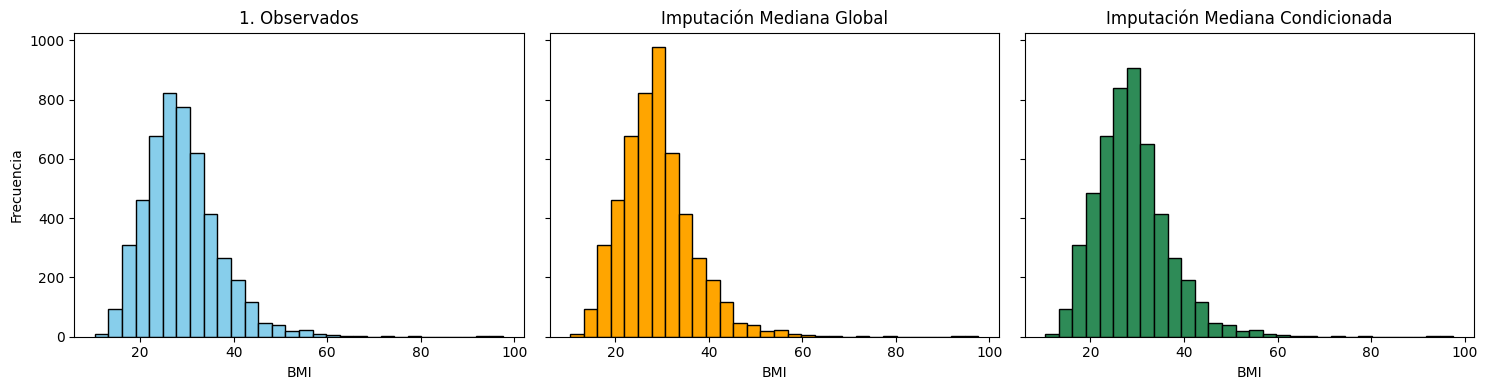


Verificación: Faltantes restantes en 'bmi' -> 0


In [2619]:
# [9] Imputacion de bmi
# TODO: (a) cree la columna indicadora bmi_faltante ANTES de imputar.
#       (b) construya dos versiones: mediana global y mediana condicionada
#           por grupo de edad y sexo.
#       (c) compare n, media, desviacion estandar y asimetria de las tres versiones
#           (observados, global, condicionada) e incluya un histograma de cada imputacion.
#       (d) elija una, aplíquela a df y verifique que no quedan nulos.

df = df[df['gender'].isin(['Male', 'Female'])].copy()

df['bmi_faltante'] = df['bmi'].isna()
bmi_observados = df['bmi'].copy()
mediana_global = df['bmi'].median()
df['bmi_global'] = df['bmi'].fillna(mediana_global)

df['grupo_edad'] = pd.cut(df['age'], bins=[0, 18, 40, 60, 120], labels=['0-18', '19-40', '41-60', '61-120'])
medianas_grupo = df.groupby(['gender', 'grupo_edad'], observed=False)['bmi'].transform('median')
df['bmi_condicionada'] = df['bmi'].fillna(medianas_grupo).fillna(mediana_global)



# (c) Comparar n, media, desviación estándar y asimetría + Histogramas
def calcular_metricas(serie, nombre):
    datos = serie.dropna() if nombre == "Observados" else serie
    return {
        "Versión": nombre,
        "n": len(datos),
        "Media": datos.mean(),
        "Desv_Estd": datos.std(),
        "Asimetría": stats.skew(datos)
    }


df_comparacion = pd.DataFrame([
    calcular_metricas(bmi_observados, "Observados"),
    calcular_metricas(df['bmi_global'], "Global"),
    calcular_metricas(df['bmi_condicionada'], "Condicionada")
])

print("--- TABLA COMPARATIVA ---")
print(df_comparacion.to_string(index=False))

# Histogramas
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

axes[0].hist(bmi_observados.dropna(), bins=30, color='skyblue', edgecolor='black')
axes[0].set_title("1. Observados")
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(df['bmi_global'], bins=30, color='orange', edgecolor='black')
axes[1].set_title("Imputación Mediana Global")
axes[1].set_xlabel("BMI")

axes[2].hist(df['bmi_condicionada'], bins=30, color='seagreen', edgecolor='black')
axes[2].set_title("Imputación Mediana Condicionada")
axes[2].set_xlabel("BMI")

plt.tight_layout()
plt.show()


# (d) Elegir una versión, aplicarla a df y verificar que no quedan nulos
df['bmi'] = df['bmi_condicionada']

# Limpieza de columnas temporales creadas para el análisis
df.drop(columns=['bmi_global', 'bmi_condicionada', 'grupo_edad'], inplace=True)

nulos_restantes = df['bmi'].isna().sum()
print(f"\nVerificación: Faltantes restantes en 'bmi' -> {nulos_restantes}")

**Justifique su elección.** ¿Qué le pasa a la desviación estándar al imputar y por qué? ¿Qué aporta
`bmi_faltante` que la imputación por sí sola pierde? ¿Y qué decidió hacer con la categoría
enmascarada de la celda [8] — imputarla o conservarla? Argumente.

La desviación estándar disminuye un poco, bmi_faltante sirve como referencia para tener una guía para obtener la mediana como tener una referencia de los valores, se decidió usar la condicionada ya que mantiene más sus valores con respecto a los datos originales

---
## Parte 4 · Valores atípicos (subtema 4.3)

--- REPORTE DE DETECCIÓN POR IQR ---
         Variable  Límite Inferior  Límite Superior  Num. Atípicos  Máximo
              age          -29.000          115.000              0   82.00
              bmi           10.050           46.450            123   97.60
avg_glucose_level           21.965          169.365            627  271.74


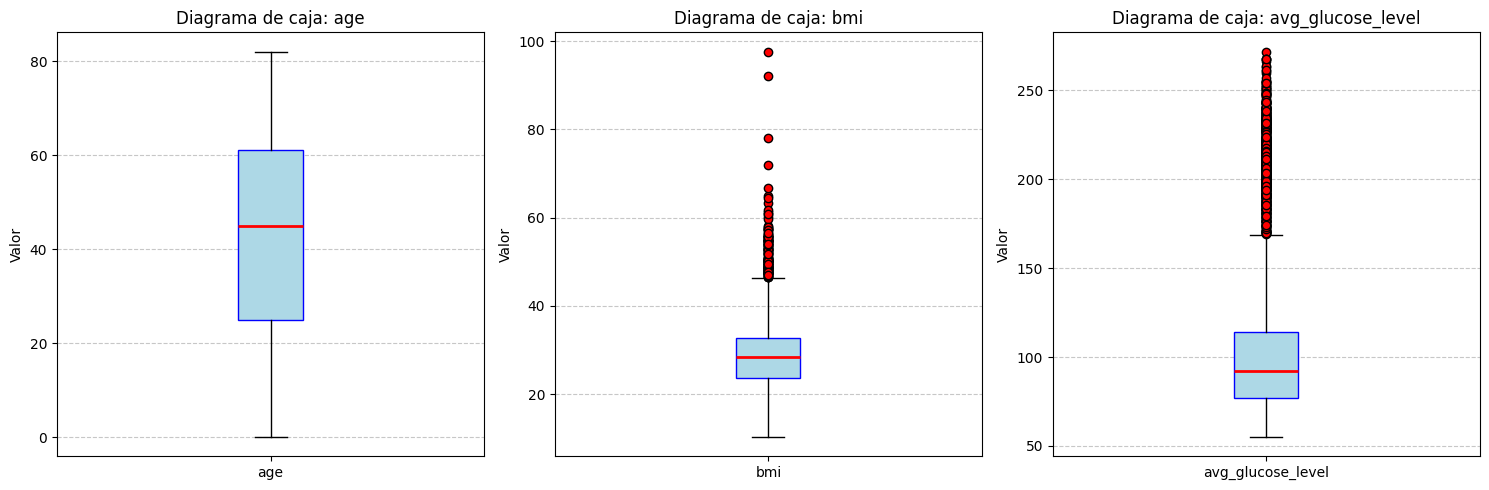

In [2620]:
# [10] Deteccion por rango intercuartil
# TODO: escriba una funcion limites_iqr(x, k=1.5) que devuelva (Q1-k*IQR, Q3+k*IQR).
#       Aplíquela a las tres numericas: reporte limites, numero de atipicos y maximo.
#       Acompane con un diagrama de caja por variable.
def limites_iqr(x, k=1.5):
    """
    Calcula los límites inferior y superior para detectar atípicos usando el método IQR.
    Acepta una Serie de pandas o array, ignorando valores nulos.
    """
    q1 = np.percentile(x.dropna(), 25)
    q3 = np.percentile(x.dropna(), 75)
    iqr = q3 - q1
    
    limite_inferior = q1 - k * iqr
    limite_superior = q3 + k * iqr
    
    return limite_inferior, limite_superior

cols_numericas = ['age', 'bmi', 'avg_glucose_level']  

resultados = []

for col in cols_numericas:
    lim_inf, lim_sup = limites_iqr(df[col], k=1.5)
    
    
    atipicos = df[(df[col] < lim_inf) | (df[col] > lim_sup)][col]
    num_atipicos = len(atipicos)
    val_maximo = df[col].max()
    
    resultados.append({
        'Variable': col,
        'Límite Inferior': round(lim_inf, 4),
        'Límite Superior': round(lim_sup, 4),
        'Num. Atípicos': num_atipicos,
        'Máximo': round(val_maximo, 4)
    })

df_reporte = pd.DataFrame(resultados)

print("--- REPORTE DE DETECCIÓN POR IQR ---")
print(df_reporte.to_string(index=False))

fig, axes = plt.subplots(1, len(cols_numericas), figsize=(5 * len(cols_numericas), 5))

for i, col in enumerate(cols_numericas):
    ax = axes[i] if len(cols_numericas) > 1 else axes
    
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='blue'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='red', markersize=6, linestyle='none'))
    
    ax.set_title(f'Diagrama de caja: {col}')
    ax.set_ylabel('Valor')
    ax.set_xticklabels([col])
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [2621]:
# [11] Un atipico no es automaticamente un error
# TODO: para bmi, compare la tasa del objetivo dentro y fuera del limite superior.
#       Cuente los registros con bmi > 60 y reporte el maximo observado.
#       Calcule la asimetria antes y despues de una winsorizacion al percentil 99.
col_target = 'stroke'

lim_inf, lim_sup = limites_iqr(df['bmi'], k=1.5)

dentro_limite = df[df['bmi'] <= lim_sup]
fuera_limite = df[df['bmi'] > lim_sup]

tasa_dentro = dentro_limite[col_target].mean()
tasa_fuera = fuera_limite[col_target].mean()

print(f"--- COMPARACIÓN DE TASA DEL OBJETIVO ({col_target}) ---")
print(f"Límite superior IQR para BMI: {lim_sup:.4f}")
print(f"Tasa objetivo DENTRO del límite (BMI <= {lim_sup:.2f}): {tasa_dentro:.4f} ({tasa_dentro*100:.2f}%)")
print(f"Tasa objetivo FUERA del límite (BMI > {lim_sup:.2f}):  {tasa_fuera:.4f} ({tasa_fuera*100:.2f}%)")

bmi_mayores_60 = (df['bmi'] > 60).sum()
max_bmi = df['bmi'].max()

print("\n--- VALORES EXTREMOS EN BMI ---")
print(f"Cantidad de registros con BMI > 60: {bmi_mayores_60}")
print(f"Máximo valor de BMI observado: {max_bmi:.4f}")

asimetria_antes = stats.skew(df['bmi'].dropna())

# Aplicar Winsorización al percentil 99 (limitar los valores extremos superiores al P99)
p99 = df['bmi'].quantile(0.99)
bmi_winsorized = df['bmi'].clip(upper=p99)

# Asimetría después de winsorizar
asimetria_despues = stats.skew(bmi_winsorized.dropna())

print("\n--- EFECTO DE LA WINSORIZACIÓN (PERCENTIL 99) ---")
print(f"Valor del Percentil 99 (P99): {p99:.4f}")
print(f"Asimetría ANTES de winsorizar:  {asimetria_antes:.4f}")
print(f"Asimetría DESPUÉS de winsorizar: {asimetria_despues:.4f}")

--- COMPARACIÓN DE TASA DEL OBJETIVO (stroke) ---
Límite superior IQR para BMI: 46.4500
Tasa objetivo DENTRO del límite (BMI <= 46.45): 0.0493 (4.93%)
Tasa objetivo FUERA del límite (BMI > 46.45):  0.0244 (2.44%)

--- VALORES EXTREMOS EN BMI ---
Cantidad de registros con BMI > 60: 13
Máximo valor de BMI observado: 97.6000

--- EFECTO DE LA WINSORIZACIÓN (PERCENTIL 99) ---
Valor del Percentil 99 (P99): 52.8920
Asimetría ANTES de winsorizar:  1.0697
Asimetría DESPUÉS de winsorizar: 0.6734


**Decida y justifique.** ¿Elimina, recorta o conserva los atípicos de `bmi`? Compare este caso con
los ceros de colesterol de la Práctica 7: ¿por qué allá la decisión fue inmediata y aquí no?
Anticipe qué implica su decisión para la Parte 8.

Es prefirible conservar los valores de bmi, ya que a pesar de ser elevado pueden ser posibles, comparado con la practica 7 un colesterol de 0 es imposible, sin embargo un bmi mayor a los rangos de obesidad/anorexia es posible

---
## Parte 5 · Ingeniería de funciones (subtema 4.2)

Hasta aquí sólo ha limpiado. Ahora **agregue** información que el modelo no deduciría solo, usando
umbrales clínicos establecidos —no cortes arbitrarios.

In [2622]:
# [12] Variables derivadas con criterio clinico
# TODO: construya al menos cuatro variables nuevas. Se sugieren:
#         - imc_cat        : clasificacion de la OMS (18.5 / 25 / 30 kg/m2)
#         - glucosa_cat    : umbrales de glucemia casual (140 / 200 mg/dL)
#         - n_comorbilidades : suma de hipertension y cardiopatia
#         - grupo_edad     : el que definio en la celda [8]
#       Para cada una, reporte el conteo y la tasa del objetivo por categoria.
#       Revise si la tasa es monotona en todas: una de ellas NO lo es.
df['imc_cat'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad'],
    right=False
)
df['glucosa_cat'] = pd.cut(
    df['avg_glucose_level'],
    bins=[0, 140, 200, np.inf],
    labels=['Normal', 'Alterada', 'Elevada'],
    right=False
)

df['n_comorbilidades'] = df['hypertension'] + df['heart_disease']

# Variable 4: Grupo de Edad (definido previamente en la celda [8])
df['grupo_edad'] = pd.cut(
    df['age'],
    bins=[0, 18, 40, 60, 120],
    labels=['0-18', '19-40', '41-60', '61-120'],
    right=False
)
variables_derivadas = ['imc_cat', 'glucosa_cat', 'n_comorbilidades', 'grupo_edad']

for var in variables_derivadas:
    reporte = df.groupby(var, observed=False)[col_target].agg(
        Conteo='count',
        Casos='sum',
        Tasa_Objetivo='mean'
    ).reset_index()
    
    # Formato de porcentaje para la tasa
    reporte['Tasa_pct'] = (reporte['Tasa_Objetivo'] * 100).round(2).astype(str) + '%'
      
    print(f"\nREPORTE PARA: {var.upper()}")
    print(reporte[['Conteo', 'Casos', 'Tasa_pct']].to_string(index=True))



REPORTE PARA: IMC_CAT
   Conteo  Casos Tasa_pct
0     337      1     0.3%
1    1263     36    2.85%
2    1558    109     7.0%
3    1951    103    5.28%

REPORTE PARA: GLUCOSA_CAT
   Conteo  Casos Tasa_pct
0    4289    156    3.64%
1     386     37    9.59%
2     434     56    12.9%

REPORTE PARA: N_COMORBILIDADES
   Conteo  Casos Tasa_pct
0    4399    149    3.39%
1     646     87   13.47%
2      64     13   20.31%

REPORTE PARA: GRUPO_EDAD
   Conteo  Casos Tasa_pct
0     856      2    0.23%
1    1313      6    0.46%
2    1564     60    3.84%
3    1376    181   13.15%


**Justifique los umbrales.** Cite el criterio clínico de cada corte. ¿Alguna de sus derivadas es
monótona respecto de la tasa del objetivo? ¿Y cuál de ellas es una discretización de una variable
que **ya tiene** en la matriz? Anótelo: va a importar en la Parte 9.

El del IMC son los umbrales de la OMS, el de la glucosa por el ADA, el rango de edad por el riesgo que conlleva en cada etapa y las comorbilidades ya que la presencia de hipertensión y una patología en el corazón aumenta las probablidades de infarto.

Son monotonas crecientes excepto el imc; las variables creadas son discretizaciones ya existentes en la matriz

---
## Parte 6 · Codificación one-hot (subtema 4.4)

In [2623]:
# [13] One-hot y el efecto del parametro drop
# TODO: con OneHotEncoder, compare el numero de columnas resultante con
#       drop=None, drop="first" y drop="if_binary".
#       Ajuste la version que elija, construya la matriz codificada y reporte su forma.
#       Identifique la columna con menor frecuencia y cuantos registros la activan.
from sklearn.preprocessing import OneHotEncoder

cols_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Variables categóricas detectadas:", cols_categoricas)

# Comparación de opciones del parámetro `drop`
for drop_param in [None, 'first', 'if_binary']:
    ohe_temp = OneHotEncoder(drop=drop_param, sparse_output=False)
    array_temp = ohe_temp.fit_transform(df[cols_categoricas])
    print(f"drop={str(drop_param):<10} -> Columnas generadas: {array_temp.shape[1]}")


encoder = OneHotEncoder(drop='first', sparse_output=False)


matriz_ohe = encoder.fit_transform(df[cols_categoricas])


nombres_columnas = encoder.get_feature_names_out(cols_categoricas)
df_ohe = pd.DataFrame(matriz_ohe, columns=nombres_columnas, index=df.index)

print(f"\n--- FORMA DE LA MATRIZ CODIFICADA ---")
print(f"Filas: {df_ohe.shape[0]}, Columnas: {df_ohe.shape[1]}")


# 4. Identificar la columna con menor frecuencia y su conteo de registros
frecuencia_columnas = df_ohe.sum().sort_values(ascending=True)

col_menos_frecuente = frecuencia_columnas.index[0]
conteo_minimo = int(frecuencia_columnas.iloc[0])

print("\n--- COLUMNA MENOS FRECUENTE ---")
print(f"Columna: {col_menos_frecuente}")
print(f"Registros que la activan (frecuencia = 1): {conteo_minimo}")

Variables categóricas detectadas: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'imc_cat', 'glucosa_cat', 'grupo_edad']
drop=None       -> Columnas generadas: 26
drop=first      -> Columnas generadas: 18
drop=if_binary  -> Columnas generadas: 23

--- FORMA DE LA MATRIZ CODIFICADA ---
Filas: 5109, Columnas: 18

--- COLUMNA MENOS FRECUENTE ---
Columna: work_type_Never_worked
Registros que la activan (frecuencia = 1): 22


In [2624]:
# [14] Una categoria nunca vista
# TODO: ajuste un codificador sobre work_type con handle_unknown="ignore" y
#       transforme un DataFrame con una categoria inexistente (por ejemplo "Pensionado").
#       Describa que devuelve y que habria pasado con handle_unknown="error".
df_entrenamiento = pd.DataFrame({
    'work_type': ['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
})

encoder_ignore = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder_ignore.fit(df_entrenamiento[['work_type']])

print("Categorías aprendidas durante el fit:")
print(encoder_ignore.categories_)

df_prueba = pd.DataFrame({
    'work_type': ['Private', 'Pensionado', 'Self-employed']
})

matriz_transformada = encoder_ignore.transform(df_prueba[['work_type']])

# Convertir a DataFrame para visualizar claramente las columnas y filas
df_resultado = pd.DataFrame(
    matriz_transformada,
    columns=encoder_ignore.get_feature_names_out(['work_type'])
)

print("\n--- MATRIZ RESULTANTE (handle_unknown='ignore') ---")
print(df_resultado)

Categorías aprendidas durante el fit:
[array(['Govt_job', 'Never_worked', 'Private', 'Self-employed', 'children'],
      dtype=object)]

--- MATRIZ RESULTANTE (handle_unknown='ignore') ---
   work_type_Govt_job  work_type_Never_worked  work_type_Private  \
0                 0.0                     0.0                1.0   
1                 0.0                     0.0                0.0   
2                 0.0                     0.0                0.0   

   work_type_Self-employed  work_type_children  
0                      0.0                 0.0  
1                      0.0                 0.0  
2                      1.0                 0.0  


**Justifique su elección de `drop`.** ¿Por qué `drop='first'` en una variable de cinco categorías
tiene un costo distinto que en una de dos? ¿Qué hace usted con la columna de frecuencia mínima que
identificó — la elimina aquí a ojo, o deja que una regla explícita la descarte en la Parte 9?

Porque drop = first, elimina una categoría que se asumirá como 0 o 1 lo que permite evitar redunancia; al ser un mayor numero de categorías se deben generar más columnas pero eliminando una quedando como 0 la primera de manera "al azar" No se eliminirá aqui hasta la parte 9

---
## Parte 7 · Transformación de la distribución (subtema 4.5)

In [2625]:
# [15] Escalera de transformaciones
# TODO: para cada variable numerica, tabule la asimetria original y despues de
#       sqrt, log1p y Yeo-Johnson, e incluya el lambda estimado.
from sklearn.preprocessing import PowerTransformer
cols_numericas = ['age', 'bmi', 'avg_glucose_level']  # Ajusta según las columnas de tu df

resultados = []

for col in cols_numericas:
    serie_orig = df[col].dropna()
    
    
    skew_orig = stats.skew(serie_orig)
    
    
    skew_sqrt = stats.skew(np.sqrt(serie_orig))
    
    
    skew_log1p = stats.skew(np.log1p(serie_orig))
    
   
    pt = PowerTransformer(method='yeo-johnson', standardize=False)
    
    datos_yj = pt.fit_transform(serie_orig.values.reshape(-1, 1)).flatten()
    skew_yj = stats.skew(datos_yj)
    lambda_yj = pt.lambdas_[0]
    
    resultados.append({
        'Variable': col,
        'Skew_Original': round(skew_orig, 4),
        'Skew_Sqrt': round(skew_sqrt, 4),
        'Skew_Log1p': round(skew_log1p, 4),
        'Skew_YeoJohnson': round(skew_yj, 4),
        'Lambda_YJ': round(lambda_yj, 4)
    })
df_escalera = pd.DataFrame(resultados)

print("--- ESCALERA DE TRANSFORMACIONES Y ASIMETRÍA ---")
print(df_escalera.to_string(index=False))

--- ESCALERA DE TRANSFORMACIONES Y ASIMETRÍA ---
         Variable  Skew_Original  Skew_Sqrt  Skew_Log1p  Skew_YeoJohnson  Lambda_YJ
              age        -0.1374    -0.7863     -1.6769          -0.2789     0.8604
              bmi         1.0697     0.4746      0.0208          -0.0007    -0.0245
avg_glucose_level         1.5724     1.2429      0.8898           0.0846    -1.0765


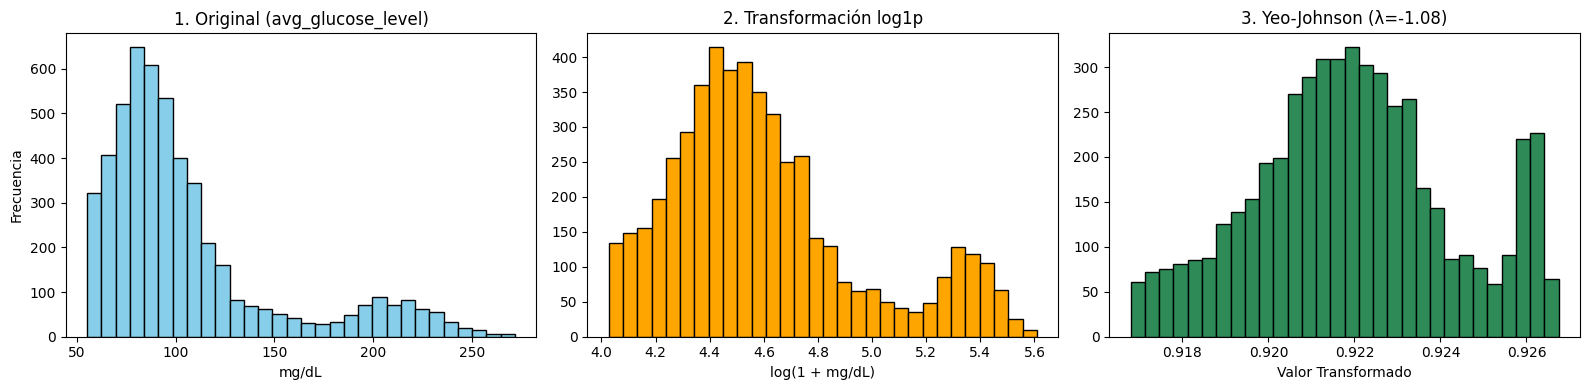

--- DISTRIBUCIÓN CLÍNICA DE AVG_GLUCOSE_LEVEL ---
             Registros  Porcentaje (%)
glucosa_cat                           
Normal            4289           83.95
Elevada            434            8.49
Alterada           386            7.56


In [2626]:
# [16] El caso dificil
# TODO: una de las tres variables mejora con el logaritmo pero NO queda simetrica.
#       Grafique su histograma original, logaritmico y Yeo-Johnson.
#       Reporte que porcentaje de pacientes cae en cada categoria clinica de esa variable.
col_dificil = 'avg_glucose_level'
serie_orig = df[col_dificil].dropna()


serie_log = np.log1p(serie_orig)

pt = PowerTransformer(method='yeo-johnson', standardize=False)
datos_yj = pt.fit_transform(serie_orig.values.reshape(-1, 1)).flatten()
serie_yj = pd.Series(datos_yj, index=serie_orig.index)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# Histograma Original
axes[0].hist(serie_orig, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title(f'1. Original ({col_dificil})')
axes[0].set_xlabel('mg/dL')
axes[0].set_ylabel('Frecuencia')

# Histograma Log1p
axes[1].hist(serie_log, bins=30, color='orange', edgecolor='black')
axes[1].set_title('2. Transformación log1p')
axes[1].set_xlabel('log(1 + mg/dL)')

# Histograma Yeo-Johnson
axes[2].hist(serie_yj, bins=30, color='seagreen', edgecolor='black')
axes[2].set_title(f'3. Yeo-Johnson (λ={pt.lambdas_[0]:.2f})')
axes[2].set_xlabel('Valor Transformado')

plt.tight_layout()
plt.show()


if 'glucosa_cat' not in df.columns:
    df['glucosa_cat'] = pd.cut(
        df['avg_glucose_level'],
        bins=[0, 140, 200, np.inf],
        labels=['Normal (<140)', 'Alterada (140-200)', 'Elevada / Diabetes (>=200)'],
        right=False
    )

# Reporte de conteo y porcentaje
conteo_cat = df['glucosa_cat'].value_counts(dropna=False)
porcentaje_cat = df['glucosa_cat'].value_counts(normalize=True, dropna=False) * 100

reporte_clinico = pd.DataFrame({
    'Registros': conteo_cat,
    'Porcentaje (%)': porcentaje_cat.round(2)
})

print(f"--- DISTRIBUCIÓN CLÍNICA DE {col_dificil.upper()} ---")
print(reporte_clinico.to_string())

**Concluya variable por variable.** Para cada una de las tres numéricas: ¿transforma o no, y con
qué? Una de ellas **empeora** con el logaritmo: identifíquela y explique por qué. Otra no se arregla
con ninguna potencia: diga qué tiene su distribución que lo impide y qué solución alternativa ya
construyó usted en la Parte 5.

En el caso del promedio de la glucosa no se va a mejorar debido a que esta es el resultado de la mezcla de dos muestras siguiendo una distribución bimodal que sale de la unimodalidad de estos métodos de transformación

---
## Parte 8 · Escalamiento (subtema 4.6)

--- COMPARACIÓN DE ESCALADORES PARA BMI ---
     Escalador  Mínimo  Máximo  Amplitud 90% Central (P95 - P5)  Asimetría
StandardScaler -2.4057  8.9026                           3.2332     1.0697
  MinMaxScaler  0.0000  1.0000                           0.2859     1.0697
  RobustScaler -1.9780  7.6154                           2.7429     1.0697


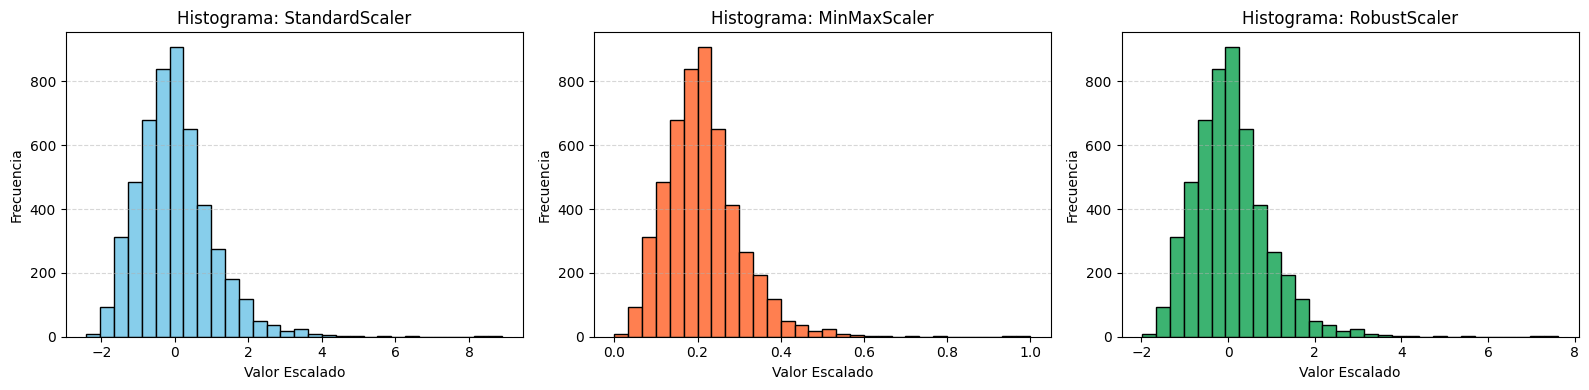

In [2627]:
# [17] Comparacion de escaladores
# TODO: aplique StandardScaler, MinMaxScaler y RobustScaler a bmi.
#       Tabule minimo, maximo, amplitud del 90 % central (p95 - p5) y asimetria.
#       Grafique los tres histogramas resultantes.
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
bmi_vals = df['bmi'].dropna().values.reshape(-1, 1)

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

datos_escalados = {}
resultados = []

for nombre, scaler in scalers.items():
    res = scaler.fit_transform(bmi_vals).flatten()
    datos_escalados[nombre] = res
    
    # Cálculo de métricas
    p5 = np.percentile(res, 5)
    p95 = np.percentile(res, 95)
    
    resultados.append({
        'Escalador': nombre,
        'Mínimo': round(float(np.min(res)), 4),
        'Máximo': round(float(np.max(res)), 4),
        'Amplitud 90% Central (P95 - P5)': round(float(p95 - p5), 4),
        'Asimetría': round(float(stats.skew(res)), 4)
    })

df_reporte_escalado = pd.DataFrame(resultados)

print("--- COMPARACIÓN DE ESCALADORES PARA BMI ---")
print(df_reporte_escalado.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

colores = ['skyblue', 'coral', 'mediumseagreen']

for idx, (nombre, datos) in enumerate(datos_escalados.items()):
    axes[idx].hist(datos, bins=30, color=colores[idx], edgecolor='black')
    axes[idx].set_title(f'Histograma: {nombre}')
    axes[idx].set_xlabel('Valor Escalado')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Explique dos cosas.** Primero: por qué la columna de asimetría es idéntica en los tres
escaladores. Segundo: cuál elige y cómo se conecta esa elección con la decisión que tomó sobre los
atípicos en la Parte 4. Diga además qué columnas **no** va a escalar y por qué.

Porque son transformaciones, no deberían de afectar la forma solo la magnitud, esto afecta sus picos más altos por haberlos mantenido, variables binarias y categoricas ya que son de 0 o 1, por lo tanto no es necesario escalarlas.

---
## Parte 9 · Selección de funciones (subtema 4.1)

Llegó con más columnas de las que empezó. Decida cuáles se quedan aplicando **tres criterios
independientes**: varianza, relevancia y redundancia. Ninguno basta por sí solo.

In [2628]:
# [18] Ensamblado de la matriz de modelado
# TODO: concatene las numericas, los indicadores, sus variables derivadas numericas
#       y la matriz one-hot en un DataFrame X. Separe el objetivo en y.
#       Reporte la forma y el listado de columnas.
y = df['stroke'].copy()
cols_derivadas_num = ['n_comorbilidades']
cols_indicadores = ['bmi_faltante', 'hypertension', 'heart_disease']
cols_num = ['age', 'bmi', 'avg_glucose_level']

X = pd.concat([
    df[cols_num],
    df[cols_indicadores],
    df[cols_derivadas_num],
    df_ohe
], axis=1)

print("--- RESUMEN DEL ENSAMBLADO ---")
print(f"Forma de X (Matriz de características): {X.shape[0]} filas × {X.shape[1]} columnas")
print(f"Forma de y (Vector objetivo):           {y.shape[0]} observaciones")

print("\n--- LISTADO DE COLUMNAS EN X ---")
for idx, col in enumerate(X.columns, 1):
    print(f"{idx:02d}. {col}")

--- RESUMEN DEL ENSAMBLADO ---
Forma de X (Matriz de características): 5109 filas × 25 columnas
Forma de y (Vector objetivo):           5109 observaciones

--- LISTADO DE COLUMNAS EN X ---
01. age
02. bmi
03. avg_glucose_level
04. bmi_faltante
05. hypertension
06. heart_disease
07. n_comorbilidades
08. gender_Male
09. ever_married_Yes
10. work_type_Never_worked
11. work_type_Private
12. work_type_Self-employed
13. work_type_children
14. Residence_type_Urban
15. smoking_status_formerly smoked
16. smoking_status_never smoked
17. smoking_status_smokes
18. imc_cat_Normal
19. imc_cat_Obesidad
20. imc_cat_Sobrepeso
21. glucosa_cat_Elevada
22. glucosa_cat_Normal
23. grupo_edad_19-40
24. grupo_edad_41-60
25. grupo_edad_61-120


In [2629]:
# [19] Criterio 1 - varianza casi nula
# TODO: aplique VarianceThreshold(0.01) y liste las columnas descartadas.
#       Muestre las cinco varianzas mas bajas.
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
selector.fit(X)

varianzas = pd.Series(selector.variances_, index=X.columns)

columnas_conservadas = X.columns[selector.get_support()]
columnas_descartadas = X.columns[~selector.get_support()]

print("--- RESULTADO DEL FILTRO DE VARIANZA CASI NULA ---")
print(f"Columnas evaluadas:   {X.shape[1]}")
print(f"Columnas conservadas: {len(columnas_conservadas)}")
print(f"Columnas descartadas: {len(columnas_descartadas)}")

print("\n--- COLUMNAS DESCARTADAS (Varianza < 0.01) ---")
if len(columnas_descartadas) > 0:
    for col in columnas_descartadas:
        print(f"- {col} (Varianza: {varianzas[col]:.6f})")
else:
    print("Ninguna columna fue descartada con el umbral de 0.01.")

cinco_menores_varianzas = varianzas.sort_values(ascending=True).head(5)

print("\n--- LAS 5 VARIANZAS MÁS BAJAS EN LA MATRIZ X ---")
for col, var in cinco_menores_varianzas.items():
    print(f"- {col:<30}: {var:.6f}")

--- RESULTADO DEL FILTRO DE VARIANZA CASI NULA ---
Columnas evaluadas:   25
Columnas conservadas: 24
Columnas descartadas: 1

--- COLUMNAS DESCARTADAS (Varianza < 0.01) ---
- work_type_Never_worked (Varianza: 0.004288)

--- LAS 5 VARIANZAS MÁS BAJAS EN LA MATRIZ X ---
- work_type_Never_worked        : 0.004288
- bmi_faltante                  : 0.037795
- heart_disease                 : 0.051104
- glucosa_cat_Elevada           : 0.077732
- hypertension                  : 0.087974


In [2630]:
# [20] Criterio 2 - relevancia frente al objetivo
# TODO: calcule mutual_info_classif y la correlacion de Pearson de cada columna con y.
#       Presente ambas en una sola tabla ordenada por informacion mutua.
from sklearn.feature_selection import mutual_info_classif
mi_scores = mutual_info_classif(X, y, discrete_features='auto', random_state=SEED)

pearson_corr = X.apply(lambda col: col.corr(y))

df_relevancia = pd.DataFrame({
    'Caracteristica': X.columns,
    'Informacion_Mutua': mi_scores,
    'Correlacion_Pearson': pearson_corr.values
})

# Ordenar por Información Mutua de mayor a menor
df_relevancia = df_relevancia.sort_values(by='Informacion_Mutua', ascending=False).reset_index(drop=True)

# Formatear números para facilitar la lectura
df_relevancia['Informacion_Mutua'] = df_relevancia['Informacion_Mutua'].round(5)
df_relevancia['Correlacion_Pearson'] = df_relevancia['Correlacion_Pearson'].round(5)

print("--- TABLA DE RELEVANCIA FRENTE AL OBJETIVO (STROKE) ---")
print(df_relevancia.to_string(index=False))

--- TABLA DE RELEVANCIA FRENTE AL OBJETIVO (STROKE) ---
                Caracteristica  Informacion_Mutua  Correlacion_Pearson
                           age            0.04079              0.24524
             grupo_edad_61-120            0.02668              0.23348
              grupo_edad_19-40            0.01192             -0.12064
                           bmi            0.00976              0.04045
            glucosa_cat_Normal            0.00916             -0.13134
                  bmi_faltante            0.00902              0.14123
                imc_cat_Normal            0.00783             -0.05385
                 heart_disease            0.00715              0.13490
              n_comorbilidades            0.00704              0.17460
              ever_married_Yes            0.00674              0.10830
          Residence_type_Urban            0.00564              0.01541
                  hypertension            0.00539              0.12789
             avg_gluc

In [2631]:
# [21] Criterio 3 - redundancia entre predictores
# TODO: (a) calcule la correlacion de age con al menos tres columnas one-hot,
#       (b) la de cada variable continua con su version discretizada de la Parte 5,
#       (c) verifique si alguna de sus variables derivadas es una combinacion lineal
#           EXACTA de otras columnas de la matriz. Si la hay, es la misma trampa
#           de la Practica 7 y debe resolverse igual.
cols_ohe_ejemplo = [c for c in df_ohe.columns if any(p in c for p in ['work_type', 'ever_married', 'smoking_status'])][:4]

corr_age_ohe = X[cols_ohe_ejemplo].apply(lambda col: X['age'].corr(col))

print("--- (a) CORRELACIÓN DE 'age' CON COLUMNAS ONE-HOT ---")
for col, val in corr_age_ohe.items():
    print(f"age vs {col:<35}: {val:.4f}")

df_temp = pd.DataFrame()
df_temp['imc_cat_num'] = df['imc_cat'].cat.codes
df_temp['glucosa_cat_num'] = df['glucosa_cat'].cat.codes
df_temp['grupo_edad_num'] = df['grupo_edad'].cat.codes

corr_continuas_discretas = {
    'bmi vs imc_cat': X['bmi'].corr(df_temp['imc_cat_num']),
    'avg_glucose_level vs glucosa_cat': X['avg_glucose_level'].corr(df_temp['glucosa_cat_num']),
    'age vs grupo_edad': X['age'].corr(df_temp['grupo_edad_num'])
}

print("\n--- (b) CORRELACIÓN ENTRE CONTINUAS Y DISCRETIZADAS ---")
for relacion, val in corr_continuas_discretas.items():
    print(f"{relacion:<35}: {val:.4f}")

if 'n_comorbilidades' in X.columns and 'hypertension' in X.columns and 'heart_disease' in X.columns:
    diferencia_exacta = X['n_comorbilidades'] - (X['hypertension'] + X['heart_disease'])
    es_combinacion_lineal = np.allclose(diferencia_exacta, 0)
    
    print("\n--- (c) VERIFICACIÓN DE COMBINACIÓN LINEAL EXACTA ---")
    print(f"¿'n_comorbilidades' es la suma exacta de 'hypertension' + 'heart_disease'?: {es_combinacion_lineal}")
    print(f"Suma de diferencias absolutas: {np.abs(diferencia_exacta).sum():.6f}")

    if es_combinacion_lineal:
        print("\n¡ALERTA!: Se detectó la 'trampa de combinación lineal exacta'.")
        print("Solución: Se debe descartar 'n_comorbilidades' de X (o eliminar las dos componentes individuales) para evitar redundancia estricta.")
        # Aplicar la solución eliminando la columna redundante derivada
        X = X.drop(columns=['n_comorbilidades'])
        print("Acción realizada: Columna 'n_comorbilidades' eliminada de la matriz X.")

--- (a) CORRELACIÓN DE 'age' CON COLUMNAS ONE-HOT ---
age vs ever_married_Yes                   : 0.6791
age vs work_type_Never_worked             : -0.0787
age vs work_type_Private                  : 0.1167
age vs work_type_Self-employed            : 0.3279

--- (b) CORRELACIÓN ENTRE CONTINUAS Y DISCRETIZADAS ---
bmi vs imc_cat                     : 0.8428
avg_glucose_level vs glucosa_cat   : 0.9070
age vs grupo_edad                  : 0.9615

--- (c) VERIFICACIÓN DE COMBINACIÓN LINEAL EXACTA ---
¿'n_comorbilidades' es la suma exacta de 'hypertension' + 'heart_disease'?: True
Suma de diferencias absolutas: 0.000000

¡ALERTA!: Se detectó la 'trampa de combinación lineal exacta'.
Solución: Se debe descartar 'n_comorbilidades' de X (o eliminar las dos componentes individuales) para evitar redundancia estricta.
Acción realizada: Columna 'n_comorbilidades' eliminada de la matriz X.


**Interprete los tres criterios.** Hay una variable cuya posición en el ranking cambia mucho según
se mida con información mutua o con correlación de Pearson: identifíquela y explique qué mide cada
criterio. Hay al menos dos columnas que son, en buena medida, la edad disfrazada: nómbrelas con su
coeficiente. Y decida el destino de **cada una** de las variables que usted construyó en la Parte 5:
diga cuáles conserva y con qué evidencia. No todas deberían sobrevivir.

avg_glucose_level daod que es bimodal y no crece de manera lineal. ever_married_yes y work_type_children están muy relacionados con la edad, n_comorbilidades, im_cat, glucosa_cat y grupo_edad deben ser eliminadas y bmi_faltante conservada esto por su baja correlación con respecto a las demas variables, sin embargo las otras, se deben retirar por ser variables redudantes que algunas nacen de la suma de datos de la propia base de datos


In [2632]:
# [22] Matriz final
# TODO: elimine las columnas que sus tres criterios descartaron, escale las continuas
#       con el escalador que eligio en la Parte 8, y reporte la forma final
#       junto con las primeras filas.
cols_ohe_ejemplo = [c for c in df_ohe.columns if any(p in c for p in ['work_type', 'ever_married', 'smoking_status'])][:4]

corr_age_ohe = X[cols_ohe_ejemplo].apply(lambda col: X['age'].corr(col))

print("--- (a) CORRELACIÓN DE 'age' CON COLUMNAS ONE-HOT ---")
for col, val in corr_age_ohe.items():
    print(f"age vs {col:<35}: {val:.4f}")



df_temp = pd.DataFrame()
df_temp['imc_cat_num'] = df['imc_cat'].cat.codes
df_temp['glucosa_cat_num'] = df['glucosa_cat'].cat.codes
df_temp['grupo_edad_num'] = df['grupo_edad'].cat.codes

corr_continuas_discretas = {
    'bmi vs imc_cat': X['bmi'].corr(df_temp['imc_cat_num']),
    'avg_glucose_level vs glucosa_cat': X['avg_glucose_level'].corr(df_temp['glucosa_cat_num']),
    'age vs grupo_edad': X['age'].corr(df_temp['grupo_edad_num'])
}

print("\n--- (b) CORRELACIÓN ENTRE CONTINUAS Y DISCRETIZADAS ---")
for relacion, val in corr_continuas_discretas.items():
    print(f"{relacion:<35}: {val:.4f}")
if 'n_comorbilidades' in X.columns and 'hypertension' in X.columns and 'heart_disease' in X.columns:
    diferencia_exacta = X['n_comorbilidades'] - (X['hypertension'] + X['heart_disease'])
    es_combinacion_lineal = np.allclose(diferencia_exacta, 0)
    
    print("\n--- (c) VERIFICACIÓN DE COMBINACIÓN LINEAL EXACTA ---")
    print(f"¿'n_comorbilidades' es la suma exacta de 'hypertension' + 'heart_disease'?: {es_combinacion_lineal}")
    print(f"Suma de diferencias absolutas: {np.abs(diferencia_exacta).sum():.6f}")

    if es_combinacion_lineal:
        print("\n¡ALERTA!: Se detectó la 'trampa de combinación lineal exacta'.")
        print("Solución: Se debe descartar 'n_comorbilidades' de X (o eliminar las dos componentes individuales) para evitar redundancia estricta.")
        # Aplicar la solución eliminando la columna redundante derivada
        X = X.drop(columns=['n_comorbilidades'])
        print("Acción realizada: Columna 'n_comorbilidades' eliminada de la matriz X.")



--- (a) CORRELACIÓN DE 'age' CON COLUMNAS ONE-HOT ---
age vs ever_married_Yes                   : 0.6791
age vs work_type_Never_worked             : -0.0787
age vs work_type_Private                  : 0.1167
age vs work_type_Self-employed            : 0.3279

--- (b) CORRELACIÓN ENTRE CONTINUAS Y DISCRETIZADAS ---
bmi vs imc_cat                     : 0.8428
avg_glucose_level vs glucosa_cat   : 0.9070
age vs grupo_edad                  : 0.9615


---
## Parte 10 · Tabla de decisiones

Complete una fila por cada columna del conjunto original. Ésta es la entrega que se califica con más
peso: es el resumen ejecutable de todo su criterio.

| Columna | Faltantes | Atípicos | Codificación | Transformación | Escalamiento | ¿Se conserva? |
|---|---|---|---|---|---|---|
| `id` |Sin faltantes |N/A |Ninguna |Ninguna |Ninguno |No |
| `gender` |Sin faltantes |N/A |One Hot |Ninguna |Ninguno |Sí |
| `age` | Sin faltantes|N/A |Ninguna |Ninguna |RobustScaler |Sí |
| `hypertension` |Sin faltantes |N/A |Ninguna |Ninguna |Ninguno |Sí |
| `heart_disease` |Sin faltantes |N/A |Ninguna |Ninguna |Ninguno |Sí |
| `ever_married` |Sin faltantes |N/A |One Hot |Ninguna |Ninguno |Sí |
| `work_type` |Sin faltantes |N/A |One Hot |Ninguna |Ninguno |Sí |
| `Residence_type` |Sin faltantes |N/A |One Hot |Ninguna |Ninguno |Sí |
| `avg_glucose_level` |Sin faltantes |Sí |Ninguna |Ninguna |RobustScaler |Sí |
| `bmi` |Imputación mediana condicionada |Sí |Ninguna |Yeo Jhensen |RobustScaler |Sí |
| `smoking_status` |Mascara "Unknown" |N/A |One Hot |Ninguna |Ninguno |Sí |

---

## Preguntas de reflexión

Responda en dos o tres párrafos cada una, apoyándose en las cifras que produjo.

1. ¿Bajo qué condición dos filas con el mismo perfil clínico **sí** serían el mismo paciente? ¿Qué
   columna tendría que existir en el conjunto para poder afirmarlo?
2. Encontró una diferencia grande en la tasa del objetivo entre pacientes con y sin `bmi`
   registrado. ¿Qué mecanismo clínico podría explicarla y por qué la imputación sola es
   insuficiente?
3. La categoría enmascarada de `smoking_status` y los ceros de colesterol de la Práctica 7 son
   ambos faltantes disfrazados. Si les dio tratamientos distintos, justifique la diferencia.
4. Una de sus variables no se corrige con ninguna transformación de potencia. ¿Por qué? ¿Qué
   propiedad de su distribución lo impide?
5. Suponga que su modelo se despliega en un hospital donde el 40 % de los expedientes llega sin
   `bmi`. ¿Qué decisión de esta tarea cambiaría y cuál mantendría?
6. ¿Qué criterio distingue una discretización útil de una redundante? Apóyese en el destino que le
   dio a sus propias variables derivadas.

1. Que tuvieran el mismo ID sin embargo no es del todo seguro, si tuvieran que suministrar alguna id oficial de esa manera uno se puede asegurar
2. Esto por MAR y MNAR ya que en casos de urgencias se suelen omitir este tipo de mediciones debido a la gravedad de la situación y usar la mediana eliminaría este contexto
3. Esto porque smoking_status posee un mayor contexto ya que puede ser por un grupo demografico y por una urgencia en cambio el colesterol en ese caso era imposible
4. Esto porque es una variable bimodal que parte de dos subpoblaciones y las transformaciones de yeo Jhensen y logaritmicas son unimodales
5. Mantendría la variable bmi_faltantes debido al contexto que otorga, usaría otro modelo de imputación para evitar generar esos picos
6. Se vuelve util cuando determina un rango real o valor posible sin embargo sería necesario borrar en ciertas ocasiones las variables de las que partieron para evitar redundancia.